In [1]:
from embedding.graph import Graph
from embedding.poincare import PoincareDisk
from embedding.embedding import Embedding

import torch
from networkit import vizbridges
from matplotlib import pyplot as plt

In [8]:
# create graph
num_data_points = 62
G = Graph()
G.create_random(num_nodes=num_data_points, min_b=2, max_b=2, mean=2.0, dev=0.01)
#vizbridges.widgetFromGraph(G.graph)

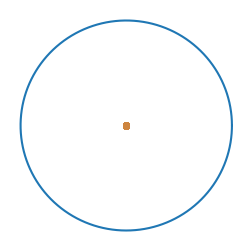

In [9]:
# create Poincare disk
D = PoincareDisk()
D.sample_random(num_points=num_data_points, radius=0.001)
D.visualize(size=3, circle=True, numbers=False)

In [10]:
# use them to create embedding object
E = Embedding(G, D)
avg_distortion_initial = E.avg_distortion_vec(E._disk.data_points, torch.arange(num_data_points))
normal_avg_distortion_initial = E.normal_avg_distortion_vec(E._disk.data_points)
print(f"Average distortion after initialization: {avg_distortion_initial}.")
print(f"Normalized average distortion after initialization: {normal_avg_distortion_initial}.")

Average distortion after initialization: 0.9996519539010783.
Normalized average distortion after initialization: 36.6706793754417.


In [11]:
# begin optimization
# good parameters: 32 nodes -> batch_size=8, 64 nodes -> batch_size=16, 128 nodes -> batch_size=32
epochs = 1000
distortions = E.RSGD(num_epochs=epochs, autograd=True, distortion="avg", batch_size=16, line_search=True, learning_rate=None, decay=None, burn_in_epochs=None)

Average distortion after 1000. epoch: 0.06454890391262838.


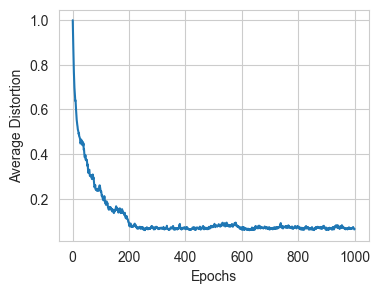

In [12]:
plt.figure(figsize=(4, 3))
plt.plot(torch.arange(epochs+1), distortions)
plt.xlabel("Epochs")
plt.ylabel("Average Distortion")
plt.show()

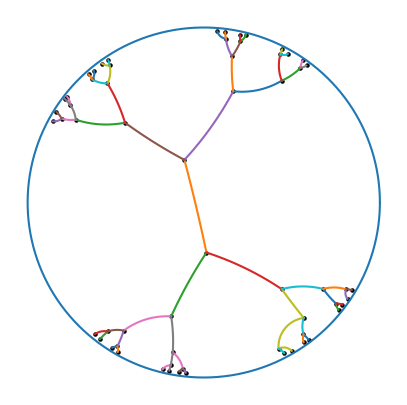

In [13]:
E.visualize(size_point=5, size_fig=5, show_circle=True, show_numbers=False, show_geodesics=True)